# Support Vector Machine (SVM)

SVM tries to separate the crop classes using boundaries between groups of data points. We scale the features because SVM is affected by differences in feature size.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
os.makedirs("../outputs", exist_ok=True)

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

## Load and Split the Dataset

We use the same 60/20/20 split as the other models.

In [2]:
df = pd.read_csv("../Dataset/Crop_recommendation_dataset.csv")
features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
X = df[features]
y = df["label"]

# First keep 20% aside for the final test set.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 25% of the remaining 80% gives 20% of the full dataset for validation.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (1320, 7)
Validation set: (440, 7)
Test set: (440, 7)


## Scale the Features

The scaler is fitted only on the training set. The same scaler is then used on validation and test data.

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## Choose C Using the Validation Set

C controls how strongly SVM tries to avoid classification mistakes. We test a small set of values and choose the one with the best validation accuracy.

C=0.1: Validation Accuracy = 0.9114
C=1: Validation Accuracy = 0.9659
C=10: Validation Accuracy = 0.9841
C=100: Validation Accuracy = 0.9864

Best C: 100


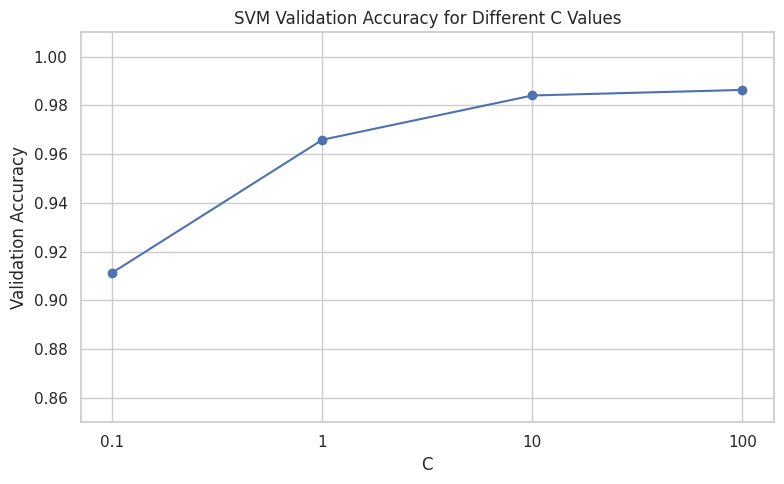

In [4]:
c_values = [0.1, 1, 10, 100]
val_accuracies = []

for c in c_values:
    model = SVC(C=c, kernel="rbf")
    model.fit(X_train_scaled, y_train)
    val_accuracy = accuracy_score(y_val, model.predict(X_val_scaled))
    val_accuracies.append(val_accuracy)
    print(f"C={c}: Validation Accuracy = {val_accuracy:.4f}")

best_c = c_values[val_accuracies.index(max(val_accuracies))]
print(f"\nBest C: {best_c}")

plt.figure(figsize=(8, 5))
plt.plot([str(c) for c in c_values], val_accuracies, marker="o")
plt.title("SVM Validation Accuracy for Different C Values")
plt.xlabel("C")
plt.ylabel("Validation Accuracy")
plt.ylim(0.85, 1.01)
plt.grid(True)
plt.tight_layout()
plt.savefig("../outputs/svm_c_selection.png", dpi=200, bbox_inches="tight")
plt.show()

## Train the Final SVM Model

After C is selected using the validation set, we combine training and validation. A new scaler is fitted on the combined 80%, then the final SVM is trained using the selected C.


In [5]:
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

final_scaler = StandardScaler()
X_train_final_scaled = final_scaler.fit_transform(X_train_final)
X_test_final_scaled = final_scaler.transform(X_test)

svm_model = SVC(C=best_c, kernel="rbf")
svm_model.fit(X_train_final_scaled, y_train_final)

print(f"Final SVM trained with C = {best_c}")
print("Final training set:", X_train_final.shape)
print("Final test set:", X_test.shape)


Final SVM trained with C = 100
Final training set: (1760, 7)
Final test set: (440, 7)


## Final Test Evaluation

The final model is evaluated on the untouched test set.

In [6]:
y_pred = svm_model.predict(X_test_final_scaled)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("SVM Final Test Statistics")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


SVM Final Test Statistics
Accuracy:  0.9886
Precision: 0.9894
Recall:    0.9886
F1-score:  0.9886

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.95      1.00      0.98        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      0.95      0.97        20
    mungbean       1.00      1.00      1.00        20
   muskmelon 

## Confusion Matrix

The confusion matrix helps us see which crop classes SVM predicts correctly and where it makes mistakes.

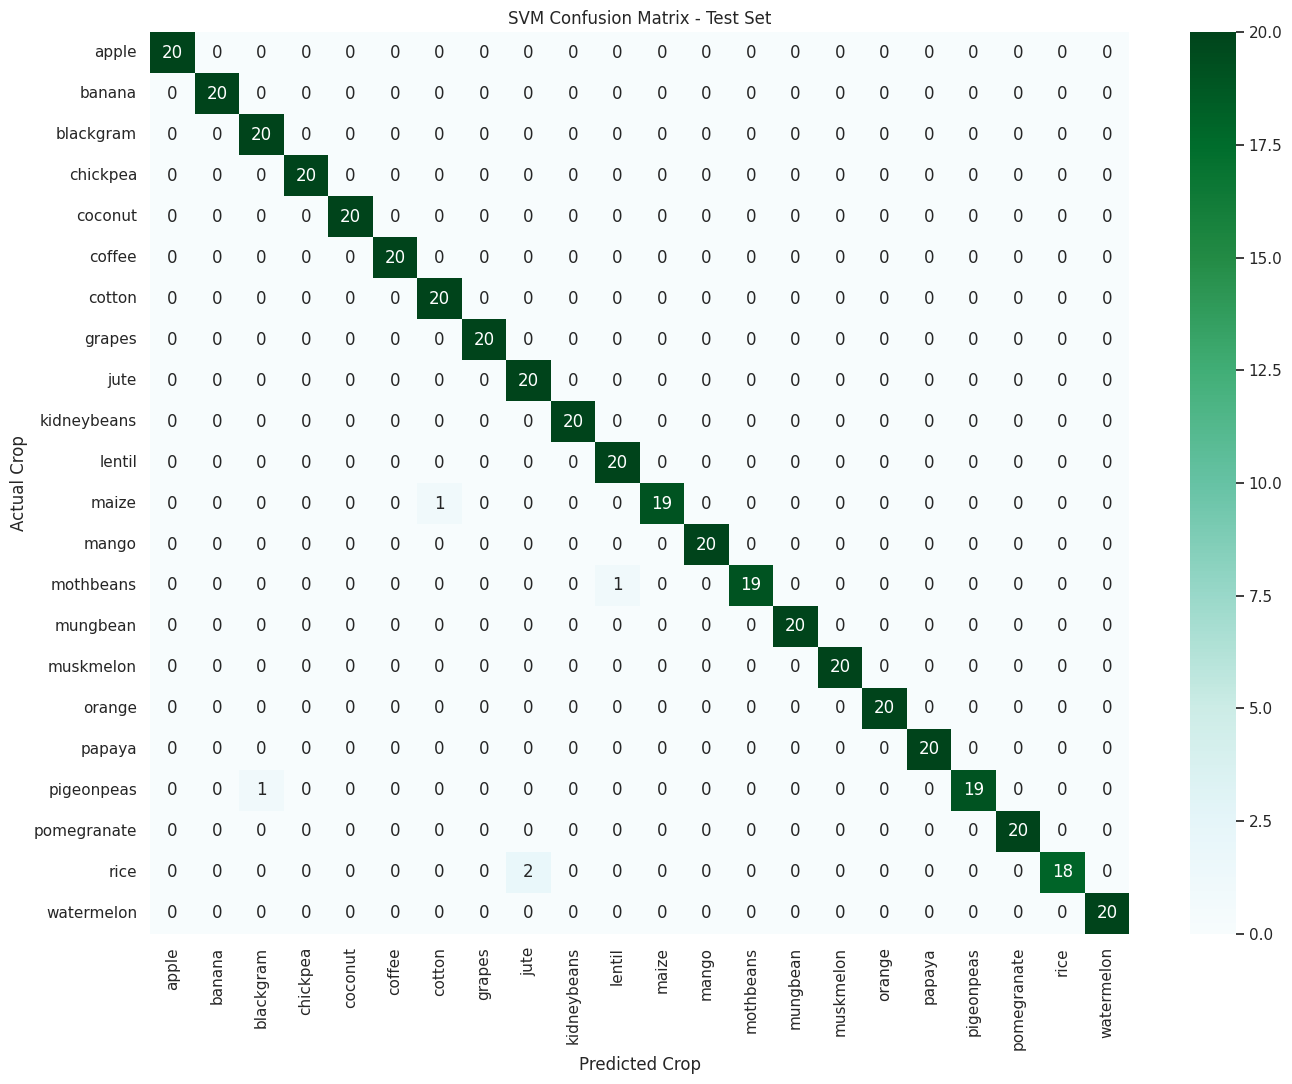

In [7]:
classes = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=classes)
plt.figure(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt="d", cmap="BuGn", xticklabels=classes, yticklabels=classes)
plt.title("SVM Confusion Matrix - Test Set")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../outputs/svm_confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

## Findings

SVM performs very well after scaling the features and choosing C with validation data. Its final test metrics will be compared with KNN, Decision Tree and Random Forest.